# Headline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download

In [3]:
!pip install vnstock
!pip install pmdarima
!pip install arch
!pip install nolds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.5/277.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 11.7 MB/s eta 0:00:00


## Import

In [4]:
from vnstock import *
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import grangercausalitytests

import nolds
from statsmodels.tsa.stattools import bds

# Data Input

In [5]:
data = pd.read_csv('/content/drive/MyDrive/COURSES/Extension Projects/Code/Data Sources/DIG_data_set.csv')
#data.drop(['target'], axis=1, inplace=True)

data

,volume_cmf,volume_em,volume_sma_em,volume_mfi,volatility_bbw,volatility_bbp,volatility_bbhi,volatility_bbli,volatility_kcw,volatility_kcp,...,momentum_pvo_signal,momentum_pvo_hist,others_dr,ret,roll_std_20,roll_skew_20,roll_kurt_20,z_score,hurst,log_ret
0,0.138525,1.084574e+00,0.290809,64.704580,8.114420,1.029340,1.0,0.0,5.819693,1.040179,...,-6.202820,2.104431,1.275510,-0.05,0.016394,1.365938,1.814575,1.288174,0.426577,-0.012674
1,0.066923,-1.089753e+00,0.198928,60.269591,8.207717,0.830410,0.0,0.0,5.653527,0.793578,...,-6.577625,-1.499221,-1.259446,0.05,0.016452,1.338127,1.706333,1.661042,0.411756,0.012674
2,0.185013,0.000000e+00,0.229390,67.519279,8.770386,0.926048,0.0,0.0,5.027209,1.072165,...,-5.820457,3.028674,1.275510,-0.13,0.018319,0.828901,1.255185,0.106307,0.401965,-0.033294
3,0.135271,-1.114451e-14,0.278248,67.325314,8.615679,0.527267,0.0,0.0,5.236326,0.412541,...,-6.016832,-0.785500,-3.274559,0.04,0.018434,0.727332,1.033995,0.514296,0.398486,0.010363
4,0.137100,-6.985273e-01,0.050120,57.877738,8.495422,0.631914,0.0,0.0,5.236326,0.610561,...,-6.385342,-1.474042,1.041667,0.12,0.019524,0.541149,0.183091,1.696173,0.395522,0.030459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,-0.260383,-6.067245e-01,0.462114,67.031890,13.011241,0.742858,0.0,0.0,6.140870,0.637349,...,-7.313110,-0.824781,-1.517341,0.21,0.023348,-1.697352,4.326719,1.282793,0.583102,0.015290
2239,-0.191036,-1.942192e-01,0.275118,68.402132,13.605116,0.829030,0.0,0.0,6.484499,0.770219,...,-6.723602,2.358035,1.540719,-0.13,0.022613,-1.687347,4.493780,0.968153,0.586032,-0.009437
2240,-0.295668,2.067160e-01,0.237358,62.845952,13.807519,0.748326,0.0,0.0,6.212909,0.571934,...,-6.880785,-0.628735,-0.939306,-0.04,0.022626,-1.662990,4.421019,0.859906,0.589697,-0.002922
2241,-0.295142,-5.696478e-01,0.235257,61.777653,13.948318,0.720561,0.0,0.0,5.825243,0.506700,...,-7.146549,-1.063054,-0.291758,0.09,0.021814,-2.001291,6.211229,0.965136,0.591952,0.006562


# Stationary test (ADF):

You must verify that all input time series are stationary before running a standard Granger Causality test.

- Why:
  - If you use non-stationary data (like raw stock prices that trend upward), the test will detect "spurious causality"—indicating a relationship where none exists simply because both series are trending over time.

- The Check:
  - Use the Augmented Dickey-Fuller (ADF) test. If the p-value is > 0.05, the data is non-stationary.

- The Fix:
  - If data is non-stationary, apply "differencing" (e.g., use returns instead of prices) until it becomes stationary.

In [6]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name):
    print(f"\n--- ADF Test for '{name}' ---")
    adf_result = adfuller(series.dropna())
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"P-value: {adf_result[1]:.4f}")
    print("Critical Values:")
    for key, value in adf_result[4].items():
        print(f"  {key}: {value:.4f}")
    if adf_result[1] < 0.05:
        print(f"Conclusion: The '{name}' series is likely stationary (p-value < 0.05).")
        return True
    else:
        print(f"Conclusion: The '{name}' series is likely non-stationary (p-value >= 0.05).")
        return False

stationary_features = []
non_stationary_features = []
for feature in [i for i in data.columns if "lag" not in i]:
    result = run_adf_test(data[feature], feature)

    if result:
        stationary_features.append(feature)
    else:
        non_stationary_features.append(feature)


--- ADF Test for 'volume_cmf' ---
ADF Statistic: -5.2373
P-value: 0.0000
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Conclusion: The 'volume_cmf' series is likely stationary (p-value < 0.05).

--- ADF Test for 'volume_em' ---
ADF Statistic: -8.4854
P-value: 0.0000
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Conclusion: The 'volume_em' series is likely stationary (p-value < 0.05).

--- ADF Test for 'volume_sma_em' ---
ADF Statistic: -9.7213
P-value: 0.0000
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Conclusion: The 'volume_sma_em' series is likely stationary (p-value < 0.05).

--- ADF Test for 'volume_mfi' ---
ADF Statistic: -7.7505
P-value: 0.0000
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Conclusion: The 'volume_mfi' series is likely stationary (p-value < 0.05).

--- ADF Test for 'volatility_bbw' ---
ADF Statistic: -4.9850
P-value: 0.0000
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Conclusion: The 'volat

## stationary and non-stationary observation:

In [7]:
print(
    f"stationary_features: {stationary_features},\n" +
    f"non_stationary_features: {non_stationary_features}"
)

stationary_features: ['volume_cmf', 'volume_em', 'volume_sma_em', 'volume_mfi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr', 'ret', 'roll_std_20', 'roll_skew_20', 'roll_kurt_20', 'z_score', 'hurst', 'log_ret'],
non_stationary_features: []


# Causality Test:

### Subtask:
Conduct Granger causality tests to determine if the lagged features Granger-cause future 'log_return' and if they Granger-cause the defined volatility measure (squared 'log_return'). This will help assess the predictive power of the features for both returns and volatility.


## Granger Causality test:

Except the "lag" variables.

In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

def get_best_granger_features(data, target_col, features, max_lag=10):
    """
    Tests Granger Causality for each feature against the target.
    Returns:
        1. best_lags: Dict {feature_name: optimal_lag}
        2. results_df: DataFrame with detailed stats
    """
    best_lags = {}
    detailed_results = []

    for feature in features:
        if feature == target_col:
            continue

        # --- CRITICAL FIX: Column Order ---
        # statsmodels tests if the SECOND column causes the FIRST column.
        # We want to know if 'feature' causes 'target_col'.
        # Therefore, order must be: [target_col, feature]
        test_df = data[[target_col, feature]].dropna()

        try:
            # verbose=False suppresses the massive text output
            test_output = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        except Exception as e:
            print(f"Skipping {feature} due to error: {e}")
            continue

        # Track the best lag for this specific feature
        best_f_score = -1
        best_lag_for_feature = -1
        is_significant = False

        for lag, result in test_output.items():
            # result[0] contains tests (F-test, etc.)
            # result[0]['ssr_ftest'] = (F-statistic, p-value, df_denom, df_num)
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]

            # Save detail
            detailed_results.append({
                'Feature': feature,
                'Lag': lag,
                'F_Statistic': f_stat,
                'P_Value': p_val
            })

            # Check for significance and max predictive power
            if p_val < 0.05:
                is_significant = True
                if f_stat > best_f_score:
                    best_f_score = f_stat
                    best_lag_for_feature = lag

        # Only keep the feature if it had at least one significant lag
        if is_significant:
            best_lags[feature] = best_lag_for_feature

    return best_lags, pd.DataFrame(detailed_results)

# --- USAGE ---

# 1. Define your features (exclude target and non-numeric)
feature_cols = [c for c in data.columns if c not in ['log_ret', 'date', 'timestamp']]

# 2. Run the Optimizer
# Note: Pass the raw 'data', not the manually shifted 'df'
# (grangercausalitytests handles the shifting internally)
optimal_lags, stats_df = get_best_granger_features(data.copy(), target_col='log_ret', features=feature_cols)

print(f"Selected {len(optimal_lags)} predictive features.")
print(optimal_lags)

verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print results
verbose is deprecated since functions should not print 

Selected 30 predictive features.
{'volume_em': np.int64(1), 'volume_sma_em': np.int64(3), 'volume_mfi': np.int64(1), 'volatility_bbp': np.int64(1), 'volatility_bbhi': np.int64(4), 'volatility_bbli': np.int64(2), 'volatility_kcw': np.int64(2), 'volatility_kcp': np.int64(1), 'volatility_kcli': np.int64(8), 'volatility_ui': np.int64(2), 'trend_macd': np.int64(2), 'trend_macd_diff': np.int64(1), 'trend_vortex_ind_pos': np.int64(1), 'trend_vortex_ind_neg': np.int64(1), 'trend_trix': np.int64(8), 'trend_dpo': np.int64(2), 'trend_kst_diff': np.int64(5), 'trend_adx_pos': np.int64(1), 'trend_adx_neg': np.int64(1), 'momentum_rsi': np.int64(1), 'momentum_tsi': np.int64(1), 'momentum_stoch': np.int64(1), 'momentum_stoch_signal': np.int64(1), 'momentum_roc': np.int64(1), 'momentum_ppo_hist': np.int64(1), 'momentum_pvo': np.int64(2), 'momentum_pvo_hist': np.int64(2), 'others_dr': np.int64(8), 'roll_skew_20': np.int64(2), 'z_score': np.int64(1)}


# ARIMAX
Combine the `return_data` DataFrame with the one-period-ahead shifted 'log_ret' from the `data` DataFrame, ensuring proper alignment and handling of NaN values, then split the resulting DataFrame into exogenous variables (`X_arima`) and the endogenous target variable (`y_arima`).

## Prepare Data for ARIMAX Model

### Subtask:
Combine the `return_data` DataFrame with the one-period-ahead shifted 'log_ret' from the `data` DataFrame, ensuring proper alignment and handling of NaN values, then split the resulting DataFrame into exogenous variables (`X_arima`) and the endogenous target variable (`y_arima`).


### causality rolling double check:

In [35]:
def build_model_dataset(data, target_col, lag_map):
    """
    Constructs X (features) and y (target) based on the optimal lags found.
    """
    X = pd.DataFrame(index=data.index)

    # 1. Create Lagged Features
    for feature, lag in lag_map.items():
        col_name = f"{feature}_lag{lag}"
        X[col_name] = data[feature].shift(lag)

    # 2. Add Target (Ensure it's aligned)
    # If we are predicting 'log_ret' at time t, we simply take log_ret at time t.
    # The features are already shifted to t-lag.
    y = data[target_col]

    # 3. Combine and Drop NaNs (created by shifting)
    final_df = pd.concat([X, y], axis=1).dropna()

    return final_df.drop(columns=[target_col]), final_df[target_col]

# Build X and y
X, y = build_model_dataset(data, 'log_ret', optimal_lags)

# Scaling for the target column is important
y = y * 100

print(f"Final Dataset Shape: {X.shape}")
display(X.head())

Final Dataset Shape: (2235, 30)


,volume_em_lag1,volume_sma_em_lag3,volume_mfi_lag1,volatility_bbp_lag1,volatility_bbhi_lag4,volatility_bbli_lag2,volatility_kcw_lag2,volatility_kcp_lag1,volatility_kcli_lag8,volatility_ui_lag2,...,momentum_tsi_lag1,momentum_stoch_lag1,momentum_stoch_signal_lag1,momentum_roc_lag1,momentum_ppo_hist_lag1,momentum_pvo_lag2,momentum_pvo_hist_lag2,others_dr_lag8,roll_skew_20_lag2,z_score_lag1
8,3.036028,0.145219,59.975766,1.099983,0.0,0.0,5.491404,1.236842,0.0,2.357961,...,28.968211,77.966102,79.647237,8.684211,0.106912,-8.014639,-1.442734,1.275510,0.367544,1.364451
9,0.000000,0.082004,59.992756,0.849974,0.0,0.0,6.761566,0.779851,0.0,2.357961,...,28.270734,62.711864,73.721924,7.446809,0.081838,-2.090583,3.585058,-1.259446,0.331131,0.906684
10,-0.793481,0.298863,61.312749,0.732559,0.0,0.0,6.759142,0.585979,0.0,2.413464,...,26.724227,55.932203,65.536723,6.382979,-0.028572,-7.250411,-1.259816,1.275510,0.382430,0.832189
11,0.786009,0.354076,66.811589,0.713452,1.0,0.0,6.334311,0.562667,0.0,2.421396,...,25.526032,55.932203,58.192090,6.382979,-0.121375,-10.499275,-3.606944,-3.274559,0.418029,1.105840
12,0.000000,0.330026,76.249014,0.783642,0.0,0.0,6.274575,0.677419,0.0,2.319676,...,25.170405,59.259259,57.041222,3.061224,-0.133612,-15.033989,-6.513326,1.041667,0.268596,0.672360


## ARIMAX Model Fitting

### Subtask:
Execute `pmdarima.auto_arima` again to determine the optimal (p, d, q) orders and fit the ARIMAX model using `y_arima` as the endogenous variable and `X_arima` as exogenous variables.

In [36]:
import pmdarima as pm
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ---------------------------------------------------------
# ASSUMPTION: You have 'X' and 'y' from the previous Granger step
# X = The DataFrame of shifted, optimal lags
# y = The target series (log_ret)
# ---------------------------------------------------------

# 1. Train/Test Split (Standard 80/20 or time-based)
train_size = int(len(y) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training on {len(y_train)} samples with {X_train.shape[1]} features.")

# 2. Initial Auto-ARIMA Search
# We find the best (p,d,q) order using the Full Granger Feature Set first.
print("\n--- Step 1: Finding Best ARIMA Orders (Auto-ARIMA) ---")
base_model = pm.auto_arima(
    y_train,
    exogenous=X_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,           # Let model determine differencing
    seasonal=False,   # Set to True if you have explicit seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

best_order = base_model.order
print(f"Best Order Found: {best_order}")

# 3. Refinement: Backward Elimination on SARIMAX
# Auto-ARIMA finds the best order, but doesn't drop insignificant exogenous vars.
# We will now loop using statsmodels to drop features with P-value > 0.05.

print("\n--- Step 2: Backward Elimination of Insignificant Features ---")
current_X_train = X_train.copy()
current_X_test = X_test.copy()

while True:
    # Fit the SARIMAX model with the current feature set
    # Note: We enforce the order found by auto_arima to keep comparisons stable
    model_sm = sm.tsa.statespace.SARIMAX(
        y_train,
        exog=current_X_train,
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    # Get p-values for just the exogenous variables (exclude ar/ma params)
    p_values = model_sm.pvalues

    # Filter to get only exogenous columns (those in our X matrix)
    # We ignore "ar.L1", "ma.L1", "sigma2" etc.
    exog_p_values = p_values[p_values.index.isin(current_X_train.columns)]

    if exog_p_values.empty:
        print("No exogenous features remaining!")
        break

    # Find the worst feature
    max_p_value = exog_p_values.max()
    worst_feature = exog_p_values.idxmax()

    # Threshold check
    if max_p_value > 0.05:
        print(f"Dropping '{worst_feature}' (p-value: {max_p_value:.4f})")
        current_X_train = current_X_train.drop(columns=[worst_feature])
        current_X_test = current_X_test.drop(columns=[worst_feature])
    else:
        print("All remaining features are significant (p < 0.05).")
        break

# 4. Final Model Summary
print("\n--- Final Refined Model Results ---")
print(model_sm.summary())

print(f"\nFinal Feature Count: {current_X_train.shape[1]}")

Training on 1788 samples with 30 features.

--- Step 1: Finding Best ARIMA Orders (Auto-ARIMA) ---
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9123.433, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=9101.435, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=9102.680, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=9102.337, Time=0.18 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=9098.018, Time=0.51 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=9096.739, Time=0.93 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=9097.967, Time=0.79 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=9098.278, Time=0.95 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9096.532, Time=0.46 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=9103.237, Time=0.20 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=9098.088, Time=0.69 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=9103.468, Time=0.30 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=9100.054, Time=3.06 sec


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'momentum_pvo_hist_lag2' (p-value: 0.9752)


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'volume_mfi_lag1' (p-value: 0.9047)


...

Maximum Likelihood optimization failed to converge. Check mle_retvals


Dropping 'volume_em_lag1' (p-value: 0.1194)


An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.


All remaining features are significant (p < 0.05).

--- Final Refined Model Results ---
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 1788
Model:               SARIMAX(1, 0, 2)   Log Likelihood               -4501.714
Date:                Fri, 06 Feb 2026   AIC                           9033.428
Time:                        15:32:57   BIC                           9115.736
Sample:                             0   HQIC                          9063.824
                               - 1788                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
volume_sma_em_lag3           -0.0368      0.006     -5.754      0.000      -0.049      -0.02

Maximum Likelihood optimization failed to converge. Check mle_retvals


## Diagnostic Tests:

### Subtask:
Perform diagnostic tests on the residuals of the re-fitted ARIMAX model. This will include the Ljung-Box test for autocorrelation at specified lags and the ARCH-LM test for heteroskedasticity. The results will indicate if the model adequately captures the dynamics of the series or if further modeling (e.g., GARCH) is required for the residuals.


In [37]:
arima_residuals = model_sm.resid

# 1. Ljung-Box Test for autocorrelation
print("\nLjung-Box Test for ARIMAX Residuals:")
ljung_box_lags = [10, 15, 20, 30]
ljung_box_results = acorr_ljungbox(arima_residuals, lags=ljung_box_lags)
print(ljung_box_results)

# 2. ARCH-LM Test for heteroskedasticity
print("\nARCH-LM Test for ARIMAX Residuals:")
arch_lm_results = het_arch(arima_residuals, nlags=10)
print(f"  F-statistic: {arch_lm_results[0]:.4f}, F-p-value: {arch_lm_results[1]:.4f}")
print(f"  Chi2-statistic: {arch_lm_results[2]:.4f}, Chi2-p-value: {arch_lm_results[3]:.4f}")


Ljung-Box Test for ARIMAX Residuals:
      lb_stat  lb_pvalue
10   6.331386   0.786696
15  24.646629   0.054895
20  31.671158   0.046931
30  54.053807   0.004534

ARCH-LM Test for ARIMAX Residuals:
  F-statistic: 378.9629, F-p-value: 0.0000
  Chi2-statistic: 47.8635, Chi2-p-value: 0.0000


# GJR-GARCH
Fit and evaluate a GARCH(1,1) model using the squared residuals from the ARIMAX model and the exogenous variables identified in the `volatility_causality` dictionary, then perform diagnostic tests on the GARCH residuals and interpret the combined ARIMAX-GARCH results.

## GARCH model

In [38]:
from arch import arch_model

# 1. Get the residuals from your optimized ARIMAX model
arimax_residuals = model_sm.resid

# 2. Configure the GARCH(1,1) Model
# vol='Garch' sets the volatility model. p=1, q=1 is the industry standard.
# dist='t' (Student's t) is often better for finance than 'Normal' (Gaussian)
# because financial returns have "fat tails" (extreme events happen more often).
garch_model = arch_model(
    arimax_residuals,
    vol='Garch',
    p=1,
    q=1,
    mean='Zero',  # IMPORTANT: We assume ARIMAX already removed the mean!
    dist='t'      # Using Student's t-distribution for fat tails
)

# 3. Fit the Model
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -4294.49
Distribution:      Standardized Student's t   AIC:                           8596.99
Method:                  Maximum Likelihood   BIC:                           8618.94
                                              No. Observations:                 1788
Date:                      Fri, Feb 06 2026   Df Residuals:                     1788
Time:                              15:32:57   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega  

**Reasoning**:
To evaluate the adequacy of the GARCH model, I will perform diagnostic tests on its standardized residuals. This includes the Ljung-Box test for autocorrelation, the ARCH-LM test for heteroskedasticity, and the BDS test for nonlinear dependencies, as these tests assess if the residuals are white noise.



## Diagnostic Tests:

In [39]:
garch_std_residuals = garch_result.resid / garch_result.conditional_volatility

print("\nLjung-Box Test for GARCH Standardized Residuals:")
ljung_box_lags = [10, 20, 30]
ljung_box_results_garch = acorr_ljungbox(garch_std_residuals, lags=ljung_box_lags)
print(ljung_box_results_garch)

print("\nARCH-LM Test for GARCH Standardized Residuals:")
arch_lm_results_garch = het_arch(garch_std_residuals, nlags=10)
print(f"  F-statistic: {arch_lm_results_garch[0]:.4f}, F-p-value: {arch_lm_results_garch[1]:.4f}")
print(f"  Chi2-statistic: {arch_lm_results_garch[2]:.4f}, Chi2-p-value: {arch_lm_results_garch[3]:.4f}")

print("\nBDS Test for GARCH Standardized Residuals:")
epsilon_garch = 1.5 * garch_std_residuals.std()
bds_stat_garch, bds_pvalue_garch = bds(garch_std_residuals, max_dim=6, epsilon=epsilon_garch)
for i in range(len(bds_stat_garch)):
    dim = i + 2
    print(f"  Dimension {dim}: z-stat = {bds_stat_garch[i]:.4f}, p-value = {bds_pvalue_garch[i]:.4f}")


Ljung-Box Test for GARCH Standardized Residuals:
      lb_stat  lb_pvalue
10   4.732828   0.908296
20  19.051676   0.518469
30  28.725612   0.532043

ARCH-LM Test for GARCH Standardized Residuals:
  F-statistic: 12.0534, F-p-value: 0.2815
  Chi2-statistic: 1.2061, Chi2-p-value: 0.2819

BDS Test for GARCH Standardized Residuals:
  Dimension 2: z-stat = 1.7449, p-value = 0.0810
  Dimension 3: z-stat = 1.0016, p-value = 0.3166
  Dimension 4: z-stat = 0.7503, p-value = 0.4531
  Dimension 5: z-stat = 0.4502, p-value = 0.6526
  Dimension 6: z-stat = 0.3332, p-value = 0.7389


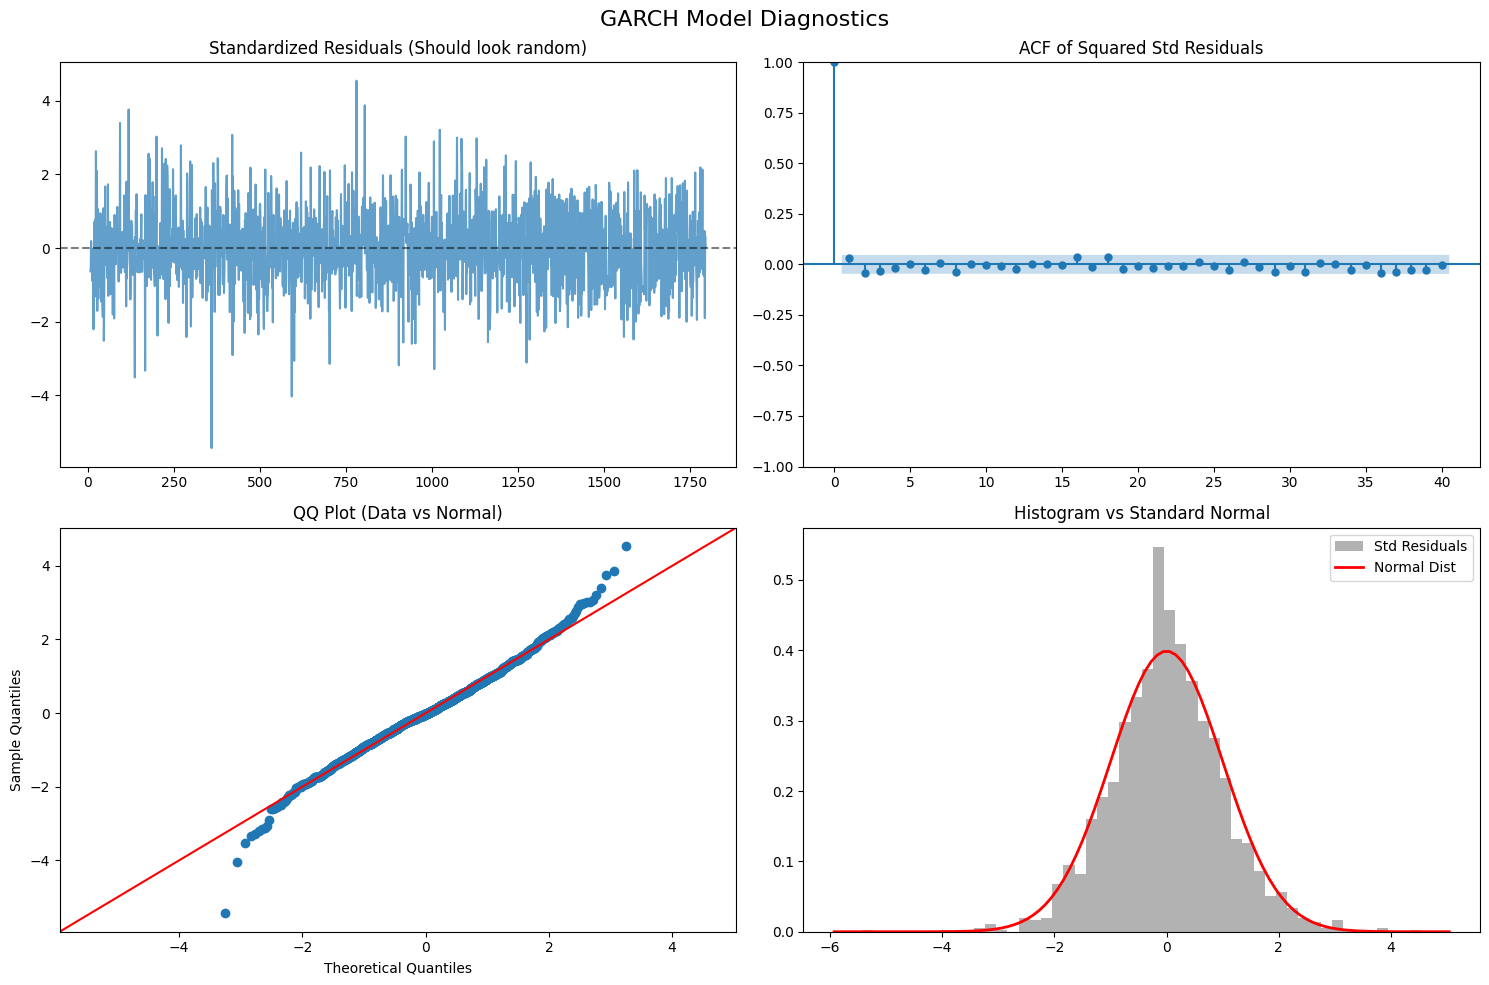


--- STATISTICAL DIAGNOSIS ---
1. Ljung-Box (Linear) p-value:   0.9083
   ✅ PASS: No significant linear correlation found.
2. Ljung-Box (Squared) p-value:  0.3237
   ✅ PASS: No significant volatility clustering found.
3. ARCH-LM Test p-value:         0.2815
   ✅ PASS: No ARCH effects detected.


In [40]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def diagnose_garch(garch_result):
    """
    Input: The fitted result object from arch_model.fit()
    Output: Plots and Statistical Tests for Model Adequacy
    """
    # 1. Get Standardized Residuals (Residuals / Sigma)
    std_resid = garch_result.std_resid

    # ---------------- VISUALIZATION ----------------
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('GARCH Model Diagnostics', fontsize=16)

    # Plot 1: Standardized Residuals over Time
    axs[0, 0].plot(std_resid, alpha=0.7)
    axs[0, 0].set_title('Standardized Residuals (Should look random)')
    axs[0, 0].axhline(0, color='black', linestyle='--', alpha=0.5)

    # Plot 2: ACF of Squared Std Residuals
    # (CRITICAL: Checks if volatility clustering was successfully removed)
    sm.graphics.tsa.plot_acf(std_resid**2, ax=axs[0, 1], lags=40, title='ACF of Squared Std Residuals')

    # Plot 3: QQ Plot (Distribution Check)
    # Compares your data to a theoretical Normal distribution
    sm.qqplot(std_resid, line='45', ax=axs[1, 0], fit=True)
    axs[1, 0].set_title('QQ Plot (Data vs Normal)')

    # Plot 4: Histogram vs Normal Curve
    axs[1, 1].hist(std_resid, bins=50, density=True, alpha=0.6, color='gray', label='Std Residuals')
    # Add normal curve for comparison
    xmin, xmax = axs[1, 1].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, 0, 1) # Standard Normal
    axs[1, 1].plot(x, p, 'r', linewidth=2, label='Normal Dist')
    axs[1, 1].set_title('Histogram vs Standard Normal')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

    # ---------------- STATISTICAL TESTS ----------------
    print("\n--- STATISTICAL DIAGNOSIS ---")

    # 1. Ljung-Box on Standardized Residuals (Linear Correlation)
    # This checks if the Mean Model (ARIMA) did its job.
    lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    lb_p = lb_test['lb_pvalue'].values[0]
    print(f"1. Ljung-Box (Linear) p-value:   {lb_p:.4f}")
    if lb_p > 0.05:
        print("   ✅ PASS: No significant linear correlation found.")
    else:
        print("   ❌ FAIL: Linear correlation remains (Check ARIMAX order).")

    # 2. Ljung-Box on SQUARED Standardized Residuals (Volatility Correlation)
    # This checks if the Volatility Model (GARCH) did its job.
    lb_sq_test = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
    lb_sq_p = lb_sq_test['lb_pvalue'].values[0]
    print(f"2. Ljung-Box (Squared) p-value:  {lb_sq_p:.4f}")
    if lb_sq_p > 0.05:
        print("   ✅ PASS: No significant volatility clustering found.")
    else:
        print("   ❌ FAIL: Volatility clustering remains (Try GARCH(2,2)).")

    # 3. Engle's ARCH-LM Test
    # Another formal test for ARCH effects
    lm_test = het_arch(std_resid)
    lm_p = lm_test[1]
    print(f"3. ARCH-LM Test p-value:         {lm_p:.4f}")
    if lm_p > 0.05:
        print("   ✅ PASS: No ARCH effects detected.")
    else:
        print("   ❌ FAIL: ARCH effects still present.")

# --- RUN IT ---
# Assuming 'garch_fit' is your fitted model variable
diagnose_garch(garch_result)